# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("unit2_ppt5_country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [ ]:
# Load Gapminder dataset
df = px.data.gapminder()

# Calculate total GDP
df["total_gdp"] = df["pop"] * df["gdpPercap"]

# Use the latest year in the dataset
latest_year = df["year"].max()
df_latest = df[df["year"] == latest_year]


# TODO 1: Choropleth of total GDP
fig = px.choropleth(
    df_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    title=f"Total GDP by Country ({latest_year})"
)
fig.show()


# TODO 2: Choropleth of GDP per capita
fig = px.choropleth(
    df_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    title=f"GDP per Capita by Country ({latest_year})"
)
fig.show()


# TODO 3: Top 5 countries by each measure
top_total = (
    df_latest
    .sort_values("total_gdp", ascending=False)
    [["country", "total_gdp"]]
    .head(5)
)

top_rate = (
    df_latest
    .sort_values("gdpPercap", ascending=False)
    [["country", "gdpPercap"]]
    .head(5)
)

print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
             country     total_gdp
1619  United States  1.293446e+13
299           China  6.539501e+12
803           Japan  4.035135e+12
707           India  2.722925e+12
575         Germany  2.650871e+12

Top 5 by GDP per capita:
             country    gdpPercap
1151         Norway  49357.19017
863          Kuwait  47306.98978
1367      Singapore  47143.17964
1619  United States  42951.65309
755         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_The top-5 countries by total GDP and GDP per capita are different. The total GDP list is dominated by countries with large populations and large economies, while the GDP per capita list contains countries with higher average income per person. For example, China and India appear among the top countries by total GDP but not among the top countries by GDP per capita, whereas smaller, wealthier countries such as Luxembourg and Norway appear in the GDP-per-capita list. If I had to pick one map to show the director, I would choose the **GDP per capita map** because it gives a clearer picture of economic output relative to population and makes differences in average economic prosperity easier to compare across countries. However, the choice depends on whether the director is interested in the overall size of an economy or economic output per person.


## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

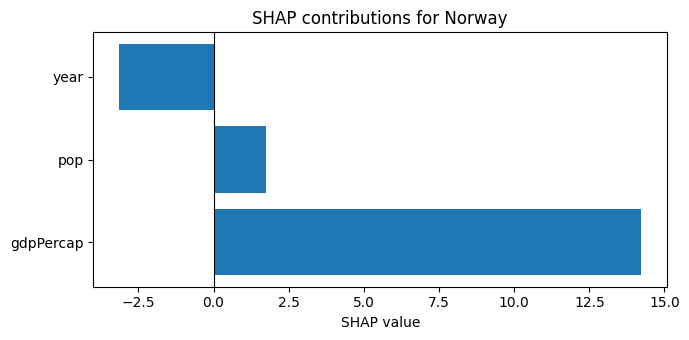

In [ ]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=0
)
rf.fit(X_model, y_model)


# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)


# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder.index[gapminder["country"] == "Norway"][0]

vals = shap_values[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))

features = ["gdpPercap", "pop", "year"]

ax.barh(features, vals)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value")
ax.set_title("SHAP contributions for Norway")

plt.tight_layout()
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_For Norway, **gdpPercap contributed the most positively** to the predicted life expectancy, while the other features had smaller contributions; any feature with a negative SHAP value pushed the prediction downward. This is not necessarily the same conclusion we would get from the model's global feature importance alone. Global feature importance describes which features are generally important across the entire dataset, whereas SHAP values for Norway explain the contribution of each feature to **this specific prediction**. Therefore, a feature can be globally important but have a negative contribution for Norway, or have a smaller global importance while still contributing positively to Norway's prediction.


## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

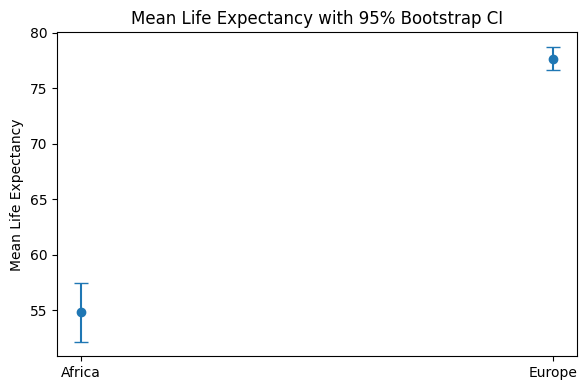

In [ ]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)

    # Resample with replacement and calculate mean for each bootstrap sample
    boot_means = []

    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(sample))

    boot_means = np.array(boot_means)

    # Return original mean and 95% bootstrap CI
    return (
        np.mean(values),
        np.percentile(boot_means, 2.5),
        np.percentile(boot_means, 97.5)
    )


# TODO 2: compute CIs for two continents
continent_a, continent_b = "Africa", "Europe"

values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)


# TODO 3: plot both as error bars
means = [result_a[0], result_b[0]]

# CI half-width = (upper CI - lower CI) / 2
errors = [
    (result_a[2] - result_a[1]) / 2,
    (result_b[2] - result_b[1]) / 2
]

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    [continent_a, continent_b],
    means,
    yerr=errors,
    fmt="o",
    capsize=5
)

ax.set_ylabel("Mean Life Expectancy")
ax.set_title("Mean Life Expectancy with 95% Bootstrap CI")

plt.tight_layout()
plt.show()

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_Africa has the **wider confidence interval** compared with Europe. Based on the lecture, the width of a confidence interval depends mainly on both the **standard deviation (SD)** and the **sample size (n)**: higher variation increases the interval width, while a smaller sample size also makes the interval wider. In this case, Africa has greater variation in life expectancy among its countries and also has more countries than Europe, so the wider interval is primarily explained by its **higher variation (SD)** rather than a smaller sample size. Therefore, the main factor contributing to Africa's wider confidence interval is its higher SD.


## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

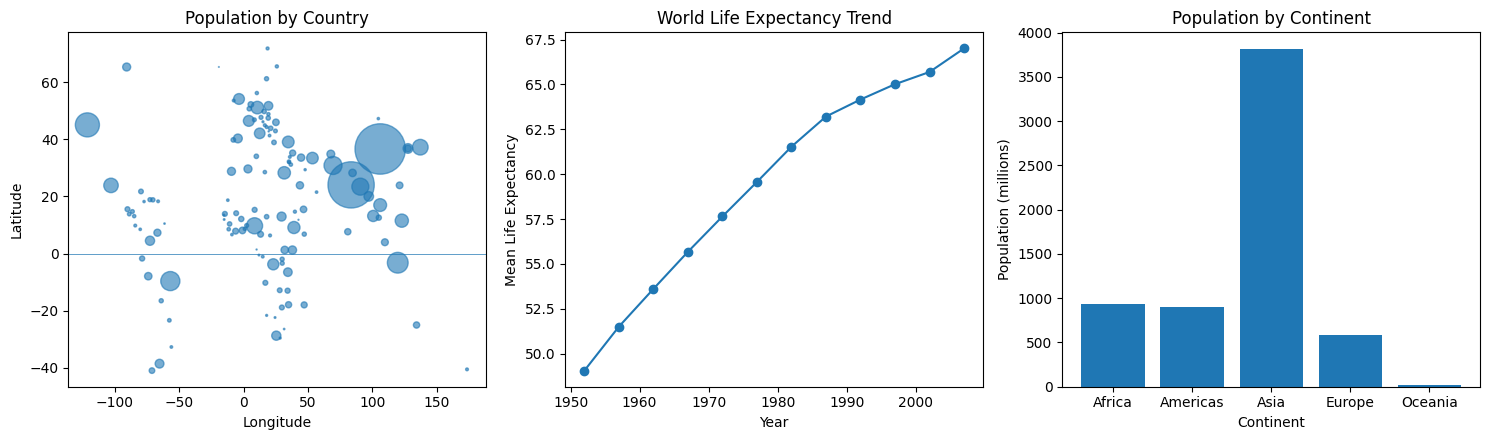

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
axes[0].scatter(
    gap_latest["centroid_lon"],
    gap_latest["centroid_lat"],
    s=gap_latest["pop"] / 1e6,
    alpha=0.6
)

axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Population by Country")
axes[0].axhline(0, linewidth=0.5)


# TODO 2: world trend line (axes[1])
world_trend = gapminder.groupby("year")["lifeExp"].mean()

axes[1].plot(
    world_trend.index,
    world_trend.values,
    marker="o"
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean Life Expectancy")
axes[1].set_title("World Life Expectancy Trend")


# TODO 3: population by continent bar chart (axes[2])
continent_pop = gap_latest.groupby("continent")["pop"].sum()

axes[2].bar(
    continent_pop.index,
    continent_pop.values / 1e6
)

axes[2].set_xlabel("Continent")
axes[2].set_ylabel("Population (millions)")
axes[2].set_title("Population by Continent")


plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_I would keep the **world trend line** because it gives the director the clearest information within a few seconds. It directly shows whether average life expectancy is increasing, decreasing, or remaining stable over time. The monitoring question it answers best is: **“Is there an important overall trend in global life expectancy that requires attention?”** This fits the lecture’s idea of monitoring **trends**, since a change in the direction or rate of the line could quickly indicate an emerging pattern that needs further investigation.


## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_ I recommend standardizing on the **rate-based map (GDP per capita)** for future reports because it accounts for population size and makes comparisons between countries more meaningful. When a journalist asks about a specific country, I would lead with **local feature importance**, because the lecture distinguishes global importance as describing the model overall, while local importance explains the contribution of features to an individual prediction. I would use global importance as supporting context rather than as the explanation for that specific country. The dashboard should never show a **mean life expectancy as a bare point estimate** without its confidence interval, because the estimate alone does not show the uncertainty or variation in the data. Showing the confidence interval helps the director understand how precise the estimate is and avoid treating an uncertain difference as a definite one.
